In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import LSTM, Embedding, TextVectorization
from tensorflow.keras.models import Model

In [3]:
# Unfortunately this URL doesn't work directly with pd.read_csv
!wget -nc https://lazyprogrammer.me/course_files/spam.csv

--2026-05-02 10:55:42--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  2.47MB/s    in 0.2s    

2026-05-02 10:55:42 (2.47 MB/s) - ‘spam.csv’ saved [503663/503663]



In [4]:
!head spam.csv

v1,v2,,,
ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,
ham,Ok lar... Joking wif u oni...,,,
spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,,,
ham,U dun say so early hor... U c already then say...,,,
ham,"Nah I don't think he goes to usf, he lives around here though",,,
spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, �1.50 to rcv",,,
ham,Even my brother is not like to speak with me. They treat me like aids patent.,,,
ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune,,,
spam,WINNER!! As a valued network customer you have been selected to receivea �900 prize reward! To claim call 09061701461. Claim 

In [5]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
# drop unnecessary columns
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# rename columns to something better
df.columns = ['labels', 'data']
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# create binary labels
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})
Y = df['b_labels'].values
# split up the data
df_train, df_test, Ytrain, Ytest = train_test_split(
    df['data'], Y, test_size=0.33)
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((df_train.values, Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((df_test.values, Ytest))
# Convert sentences to sequences
MAX_VOCAB_SIZE = 20000
vectorization = TextVectorization(max_tokens=MAX_VOCAB_SIZE)
vectorization.adapt(train_ds.map(lambda x, y: x))
# Shuffle and batch the dataset
train_ds = train_ds.shuffle(
    buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [9]:
V = len(vectorization.get_vocabulary())
# Create the model

# We get to choose embedding dimensionality
D = 20

# Hidden state dimensionality
M = 15

# if string not specified, will get string -> float casting error
i = Input(shape=(1,), dtype=tf.string)
x = vectorization(i)
x = Embedding(V , D)(x)
x = LSTM(M, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [10]:
# Compile and fit
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


print('Training model...')
r = model.fit(
  train_ds,
  epochs=10,
  validation_data=test_ds
)

Training model...
Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.8511 - loss: 0.4918 - val_accuracy: 0.8597 - val_loss: 0.3982
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8947 - loss: 0.2933 - val_accuracy: 0.9734 - val_loss: 0.1890
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9861 - loss: 0.1028 - val_accuracy: 0.9837 - val_loss: 0.0947
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9944 - loss: 0.0471 - val_accuracy: 0.9826 - val_loss: 0.0834
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9973 - loss: 0.0289 - val_accuracy: 0.9804 - val_loss: 0.0817
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9976 - loss: 0.0201 - val_accuracy: 0.9804 - val_loss: 0.0824
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9984 - loss: 0.0156 - val_accuracy: 0.9804 - val_loss: 0.0848
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9989 - loss:

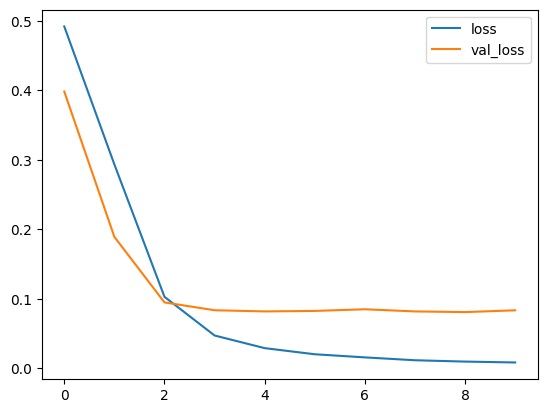

In [11]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

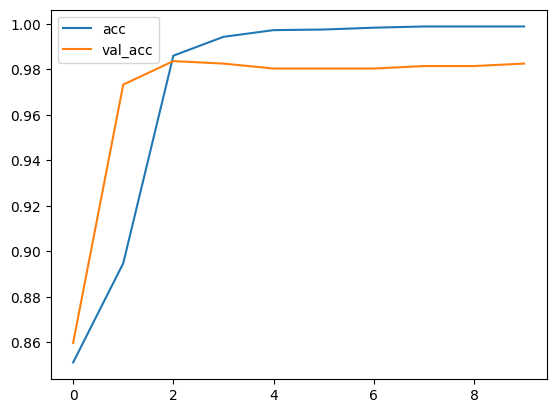

In [12]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [13]:
from sklearn.metrics import f1_score
f1_score(Ytrain, model.predict(df_train.values) > 0.5)
f1_score(Ytest, model.predict(df_test.values) > 0.5)
# What if we pre-convert strings to ints?
train_ints = vectorization(df_train.values)
test_ints = vectorization(df_test.values)
train_ints.shape
test_ints.shape # since they are different, we can't choose fixed "T" for model
# notice how there's lots of padding
train_ints[:5]
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_ints, Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((test_ints, Ytest))
# shuffle and batch the dataset
train_ds = train_ds.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [ ]:
# Create the model

# We get to choose embedding dimensionality
D = 20

# Hidden state dimensionality
M = 15

# if string not specified, will get string -> float casting error
i = Input(shape=(None,))
x = Embedding(V, D)(i)
x = LSTM(M, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)
# Compile and fit
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Training model...')
r = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)